In [3]:
# === Combined evaluation: test_hires + test_lores ==================================
from pathlib import Path
import importlib.util, json, time, re
import numpy as np

# --------- Paths (edit if needed) ----------
RUN_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813")
TEST_DIRS = [
    Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires"),
    Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_lores"),
]
TRAIN_MOD = Path("/home/rbielski/stroke_cleaned/stroke_segmentation_v1.2/stroke_seg_v1.2_train.py")
THRESH    = 0.50             # hard-Dice threshold
DEDUP_POLICY = "first"       # "first" (keep first seen), or "prefer_hires" (if dir name contains 'hires')

# --------- Utilities ----------
def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name or "")
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

def dice_soft(y, p):
    y = y.astype(np.float64); p = p.astype(np.float64)
    inter = (y*p).sum()
    return float((2.0*inter) / (y.sum() + p.sum() + 1e-12))

def dice_hard(y, p, th=0.5):
    pb = (p >= th).astype(np.float64)
    inter = (y*pb).sum()
    return float((2.0*inter) / (y.sum() + pb.sum() + 1e-12))

# ---- Import training module (for loader + custom layers) ----
spec = importlib.util.spec_from_file_location("arc_seg_train", TRAIN_MOD)
seg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seg)

# ---- Load model (.keras preferred) ----
models_dir    = RUN_DIR / "models"
callbacks_dir = RUN_DIR / "callbacks"
full_models   = sorted(models_dir.glob("*.keras"))
best_weights  = callbacks_dir / "best_model_dynamic.weights.h5"
cfg_json_path = models_dir / "config.json"

custom_objects = {
    "ResidualConvBlock": seg.ResidualConvBlock,
    "VisionMambaBlock": seg.VisionMambaBlock,
    "SAM2Attention": seg.SAM2Attention,
    "CombinedLoss": seg.CombinedLoss,
    "dice_coefficient": seg.dice_coefficient,
    "dice_loss": seg.dice_loss,
    "boundary_loss": seg.boundary_loss,
}

try:
    from keras.saving import load_model as keras_load_model
except Exception:
    from tensorflow.keras.models import load_model as keras_load_model

if full_models:
    model_path = full_models[-1]
    print(f"Loading FULL model: {model_path}")
    model = keras_load_model(model_path, compile=False, custom_objects=custom_objects)
    INPUT_SHAPE = tuple(model.input_shape[1:])
else:
    assert cfg_json_path.exists(), f"Missing {cfg_json_path}"
    with open(cfg_json_path) as f: saved_cfg = json.load(f)
    cfg = seg.DynamicTrainingConfig(
        DATA_DIR=TEST_DIRS[0],  # dummy
        MODEL_DIR=models_dir,
        CALLBACKS_DIR=callbacks_dir,
        INPUT_SHAPE=tuple(saved_cfg["INPUT_SHAPE"]) if saved_cfg.get("INPUT_SHAPE") else None,
        BASE_FILTERS=int(saved_cfg.get("BASE_FILTERS", 8)),
        SAM_HEADS=int(saved_cfg.get("SAM_HEADS", 2)),
    )
    assert cfg.INPUT_SHAPE, "INPUT_SHAPE missing in config.json."
    INPUT_SHAPE = cfg.INPUT_SHAPE
    print("Rebuilding model from config.json and loading best weights…")
    model = seg.build_dynamic_model(cfg)
    model.load_weights(str(best_weights))

print("INPUT_SHAPE:", INPUT_SHAPE)

# ---- Build combined pair list from both roots, dedup by key ----
combined_pairs = []
for root in TEST_DIRS:
    if not root.exists(): 
        print(f"(skip) Missing test dir: {root}")
        continue
    # Prefer separated subfolders if present
    t1_dir  = root / "t1"
    msk_dir = root / "masks"
    if t1_dir.exists() and msk_dir.exists():
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=root, IMAGES_DIR=t1_dir, MASKS_DIR=msk_dir,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    else:
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=root,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    cfg_eval.INPUT_SHAPE = INPUT_SHAPE
    pairs, _ = seg.load_generic_dataset(cfg_eval)
    # tag each with source root name for optional dedup preference
    combined_pairs += [(img_p, msk_p, root.name.lower()) for (img_p, msk_p) in pairs]

# Deduplicate same subject across hires/lores
by_key = {}
for img_p, msk_p, src in combined_pairs:
    k = _norm_key(img_p.stem)
    if k not in by_key:
        by_key[k] = (img_p, msk_p, src)
    else:
        if DEDUP_POLICY == "prefer_hires":
            # Replace if current is hires and stored is not
            cur_is_hires  = "hire" in src  # 'hires' contains 'hire'
            prev_is_hires = "hire" in by_key[k][2]
            if cur_is_hires and not prev_is_hires:
                by_key[k] = (img_p, msk_p, src)
        # else "first": keep first occurrence

pairs = [(v[0], v[1]) for v in by_key.values()]
print(f"Combined unique cases: {len(pairs)}")

# ---- Evaluate over combined set ----
macro_softs, macro_hards = [], []
s_inter_soft = np.float64(0.0)
s_sumy_soft  = np.float64(0.0)
s_sump_soft  = np.float64(0.0)

for i, (img_p, msk_p) in enumerate(pairs, 1):
    img = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
    y   = seg._load_and_preprocess_mask(str(msk_p),  INPUT_SHAPE[:-1]).astype(np.float32)
    x = np.zeros((1,*INPUT_SHAPE), np.float32); x[0,...,0] = img
    p = model.predict(x, verbose=0)[0,...,0].astype(np.float32)

    ds = dice_soft(y, p)
    dh = dice_hard(y, p, th=THRESH)
    macro_softs.append(ds); macro_hards.append(dh)

    # micro-soft accumulators
    s_inter_soft += (y.astype(np.float64) * p.astype(np.float64)).sum()
    s_sumy_soft  += y.sum(dtype=np.float64)
    s_sump_soft  += p.sum(dtype=np.float64)

    if i % 10 == 0 or i == len(pairs):
        print(f"[{i}/{len(pairs)}] last case soft={ds:.4f} hard@{THRESH:.2f}={dh:.4f}")

macro_soft = float(np.mean(macro_softs)) if macro_softs else float("nan")
macro_hard = float(np.mean(macro_hards)) if macro_hards else float("nan")
micro_soft = float((2.0*s_inter_soft) / (s_sumy_soft + s_sump_soft + 1e-12)) if s_sumy_soft > 0 else float("nan")

# Compute micro-hard in a second pass (memory-safe)
s_inter_hard = np.float64(0.0)
s_sumy_hard  = np.float64(0.0)
s_sump_hard  = np.float64(0.0)
for img_p, msk_p in pairs:
    y = seg._load_and_preprocess_mask(str(msk_p), INPUT_SHAPE[:-1]).astype(np.float32)
    x = np.zeros((1,*INPUT_SHAPE), np.float32)
    x[0,...,0] = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
    p  = model.predict(x, verbose=0)[0,...,0]
    pb = (p >= THRESH).astype(np.float64)
    s_inter_hard += (y.astype(np.float64) * pb).sum()
    s_sumy_hard  += y.sum(dtype=np.float64)
    s_sump_hard  += pb.sum(dtype=np.float64)

micro_hard = float((2.0*s_inter_hard) / (s_sumy_hard + s_sump_hard + 1e-12)) if s_sumy_hard > 0 else float("nan")

print("\n=== COMBINED (HIRES+LORES) RESULTS ===")
print(f"Per-case (macro) soft Dice       : {macro_soft:.4f}")
print(f"Per-case (macro) hard Dice @ {THRESH:.2f}: {macro_hard:.4f}")
print(f"Global (micro) soft Dice         : {micro_soft:.4f}")
print(f"Global (micro) hard Dice @ {THRESH:.2f} : {micro_hard:.4f}")
print(f"N cases (unique): {len(pairs)}")

# ---- Save CSV + JSON into this run ----
out_dir = RUN_DIR / "test_eval_combined"
out_dir.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")

# per-case CSV
csv_path = out_dir / f"test_metrics_COMBINED_{ts}.csv"
with open(csv_path, "w") as f:
    f.write("case,soft_dice,hard_dice_at_{:.2f}\n".format(THRESH))
    for (img_p, _), ds, dh in zip(pairs, macro_softs, macro_hards):
        f.write(f"{img_p.stem},{ds:.6f},{dh:.6f}\n")

# summary JSON
summary = {
    "threshold": THRESH,
    "macro_soft": macro_soft,
    "macro_hard": macro_hard,
    "micro_soft": micro_soft,
    "micro_hard": micro_hard,
    "n_cases": len(pairs),
    "run_dir": str(RUN_DIR),
    "sources": [str(p) for p in TEST_DIRS],
    "dedup_policy": DEDUP_POLICY,
}
json_path = out_dir / f"test_metrics_summary_COMBINED_{ts}.json"
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nWrote per-case CSV ->", csv_path)
print("Wrote summary JSON ->", json_path)


2025-11-11 15:01:44.598338: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1762898506.388513 1756240 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1762898506.389492 1756240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5445 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1762898506.389752 1756240 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 1
I0000 00:00:1762898506.390866 1756240 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 21280 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9
2025-11-11 15:01:46,435 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2025-11-11 15:01:46,435 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2025-11-11 15:01:46,436 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow

Strategy: MirroredStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/models/smart_sota_dynamic_20251110_101813.keras


2025-11-11 15:01:47,789 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2025-11-11 15:01:47,790 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=1.00GB | GPU mem tracking failed | Disk: 1229.1GB free
2025-11-11 15:01:47,795 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires/t1), masks=138 (/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires/masks)
2025-11-11 15:01:47,795 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2025-11-11 15:02:05,951 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2025-11-11 15:02:05,952 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2025-11-11 15:02:05,953 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=1.00GB | GPU mem tracking failed | Disk: 1229.1GB free
2025-11-11 15:02:05,954 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2025-11-11 15:02:05,954 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=1.00GB | GPU mem tracking failed | Disk: 1229.1GB free
2025-11-11 15:02:05,960 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=198 (/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_lores/t1), masks=198 (/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_lores/masks)

Combined unique cases: 336


2025-11-11 15:02:33.124015: I external/local_xla/xla/service/service.cc:163] XLA service 0x765e60002c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-11 15:02:33.124041: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-11-11 15:02:33.124048: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-11-11 15:02:33.222682: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-11 15:02:33.496185: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91001
I0000 00:00:1762898559.756099 1756716 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[10/336] last case soft=0.8617 hard@0.50=0.8619
[20/336] last case soft=0.8667 hard@0.50=0.8670
[30/336] last case soft=0.8474 hard@0.50=0.8476
[40/336] last case soft=0.5685 hard@0.50=0.5682
[50/336] last case soft=0.7938 hard@0.50=0.7943
[60/336] last case soft=0.8585 hard@0.50=0.8585
[70/336] last case soft=0.8423 hard@0.50=0.8431
[80/336] last case soft=0.6236 hard@0.50=0.6262
[90/336] last case soft=0.8067 hard@0.50=0.8073
[100/336] last case soft=0.0312 hard@0.50=0.0313
[110/336] last case soft=0.6186 hard@0.50=0.6209
[120/336] last case soft=0.5342 hard@0.50=0.5356
[130/336] last case soft=0.4264 hard@0.50=0.4294
[140/336] last case soft=0.7924 hard@0.50=0.7926
[150/336] last case soft=0.0000 hard@0.50=0.0000
[160/336] last case soft=0.3476 hard@0.50=0.3475
[170/336] last case soft=0.9023 hard@0.50=0.9023
[180/336] last case soft=0.8937 hard@0.50=0.8938
[190/336] last case soft=0.7514 hard@0.50=0.7513
[200/336] last case soft=0.0001 hard@0.50=0.0000
[210/336] last case soft=0.34

In [1]:
# === Join latest COMBINED (hires+lores) eval with manifest; compute summaries ===
from pathlib import Path
import csv, re, math, time
import numpy as np
import nibabel as nib

# --------- CONFIG (adjust if needed) ----------
RUN_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813")
EVAL_DIR  = RUN_DIR / "test_eval_combined"
MANIFEST  = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/combined_hires_lores_manifest.csv")
# ---------------------------------------------

def _latest_combined_csv(eval_dir: Path) -> Path:
    cands = sorted(eval_dir.glob("test_metrics_COMBINED_*.csv"), key=lambda p: p.stat().st_mtime)
    if not cands:
        raise FileNotFoundError(f"No combined eval CSVs in {eval_dir}")
    return cands[-1]

def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name or "")
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

def _to_float(x):
    try: return float(x)
    except Exception: return float("nan")

def _to_int(x):
    try: return int(float(x))
    except Exception: return 0

# --- Load manifest keyed by `key` ---
manifest = {}
with open(MANIFEST, newline="") as f:
    for row in csv.DictReader(f):
        k = (row.get("key") or "").strip()
        if not k:
            # derive from t1_path/mask_path if key missing
            for src in (row.get("t1_path"), row.get("mask_path")):
                if src:
                    k = _norm_key(Path(src).name)
                    break
        if not k:
            continue
        manifest[k] = {
            "dataset": row.get("dataset", ""),
            "t1_path": row.get("t1_path", ""),
            "mask_path": row.get("mask_path", ""),
            "fwhm_mm": _to_float(row.get("fwhm_mm", "")),
            "hi_freq_energy": _to_float(row.get("hi_freq_energy", "")),
            "lap_var": _to_float(row.get("lap_var", "")),
            "score": _to_float(row.get("score", "")),
            "bin": row.get("bin", ""),
            "mask_voxels": _to_int(row.get("mask_voxels", "")),
            "mask_ml": _to_float(row.get("mask_ml", "")),
            "mask_voxels_clean": _to_int(row.get("mask_voxels_clean", "")),
            "mask_ml_clean": _to_float(row.get("mask_ml_clean", "")),
            "brain_frac": _to_float(row.get("brain_frac", "")),
            "vox_total": _to_int(row.get("vox_total", "")),
            "norm_img_nonzero": _to_int(row.get("norm_img_nonzero", "")),
            "brain_voxels": _to_int(row.get("brain_voxels", "")),
            "voxel_mm3": _to_float(row.get("voxel_mm3", "")),
        }

print("Manifest rows:", len(manifest))

# --- Load latest COMBINED eval CSV (has columns: case, soft_dice, hard_dice_at_0.50) ---
EVAL_CSV = _latest_combined_csv(EVAL_DIR)
print("Using combined eval CSV:", EVAL_CSV)

rows_eval = []
with open(EVAL_CSV, newline="") as f:
    rd = csv.DictReader(f)
    cols = [c for c in (rd.fieldnames or []) if c]
    # Find hard column name
    hard_col = None
    for c in cols:
        if c == "hard_dice" or c.startswith("hard_dice_at_"):
            hard_col = c; break
    if hard_col is None: hard_col = "hard_dice_at_0.50"
    # Combined CSV uses 'case' (filename stem). Normalize to manifest key.
    for row in rd:
        k = _norm_key(row.get("case") or row.get("key") or "")
        if not k: continue
        rows_eval.append({
            "key": k,
            "soft_dice": _to_float(row.get("soft_dice", "")),
            "hard_dice": _to_float(row.get(hard_col, "")),
        })
print("Eval rows:", len(rows_eval))

# --- Recompute lesion size when missing/zero ---
def _recompute_size(mask_path: str, voxel_mm3: float):
    try:
        m = np.asanyarray(nib.load(mask_path).get_fdata())
        vox = int((m > 0).sum())
        ml  = float(vox * (voxel_mm3 if not math.isnan(voxel_mm3) and voxel_mm3 > 0 else 1.0) / 1000.0)
        return vox, ml
    except Exception:
        return 0, float("nan")

joined, missing, recomputed = [], 0, 0
for r in rows_eval:
    info = manifest.get(r["key"])
    if not info:
        missing += 1
        continue
    vox = info["mask_voxels_clean"] or info["mask_voxels"] or 0
    ml  = info["mask_ml_clean"] if not math.isnan(info["mask_ml_clean"]) else info["mask_ml"]
    if vox == 0:
        v2, m2 = _recompute_size(info["mask_path"], info["voxel_mm3"])
        vox, ml = v2, m2
        recomputed += 1
    joined.append({
        "key": r["key"],
        "soft_dice": r["soft_dice"],
        "hard_dice": r["hard_dice"],
        "voxels_clean": int(vox),
        "ml_clean": float(ml) if (ml is not None and not math.isnan(ml)) else float("nan"),
        "fwhm_mm": info["fwhm_mm"],
        "hi_freq_energy": info["hi_freq_energy"],
        "lap_var": info["lap_var"],
        "score": info["score"],
        "brain_frac": info["brain_frac"],
        "vox_total": info["vox_total"],
        "dataset": info["dataset"],
        "bin": info["bin"],
        "mask_path": info["mask_path"],
        "voxel_mm3": info["voxel_mm3"],
    })

print(f"Joined cases: {len(joined)} | Missing in manifest: {missing} | Recomputed sizes: {recomputed}")

# --- Correlations & summaries ---
def _col(name, dtype=np.float64):
    return np.array([row[name] for row in joined], dtype=dtype)

def nan_pearson(x, y):
    m = (~np.isnan(x)) & (~np.isnan(y))
    if m.sum() < 3: return float("nan")
    return float(np.corrcoef(x[m], y[m])[0,1])

if joined:
    soft = _col("soft_dice"); hard = _col("hard_dice"); vox = _col("voxels_clean")
    fwhm = _col("fwhm_mm"); hfe = _col("hi_freq_energy"); lapv = _col("lap_var")
    score = _col("score"); bfr = _col("brain_frac")
    log_vox = np.log10(np.where(vox > 0, vox, np.nan))

    print("\n=== Correlations (Pearson r) — COMBINED (hires+lores) ===")
    print(f"r(soft_dice, log10(lesion_vox)) = {nan_pearson(soft, log_vox):.3f}")
    print(f"r(hard_dice, log10(lesion_vox)) = {nan_pearson(hard, log_vox):.3f}")
    print(f"r(soft_dice, fwhm_mm)           = {nan_pearson(soft, fwhm):.3f}")
    print(f"r(soft_dice, hi_freq_energy)    = {nan_pearson(soft, hfe):.3f}")
    print(f"r(soft_dice, lap_var)           = {nan_pearson(soft, lapv):.3f}")
    print(f"r(soft_dice, score)             = {nan_pearson(soft, score):.3f}")
    print(f"r(soft_dice, brain_frac)        = {nan_pearson(soft, bfr):.3f}")

    # size-bin summary
    bins = [0, 2500, 10000, 30000, 60000, 10**9]
    labels = ["[0,2.5k)", "[2.5k,10k)", "[10k,30k)", "[30k,60k)", "[60k,+inf)"]
    print("\n=== Size-bin summary (voxels_clean) — COMBINED ===")
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        m = (vox >= lo) & (vox < hi)
        n = int(m.sum())
        ms = float(np.nanmean(soft[m])) if n > 0 else float("nan")
        mh = float(np.nanmean(hard[m])) if n > 0 else float("nan")
        print(f"{labels[i]:>12} | n={n:3d} | mean soft={ms:.4f} | mean hard={mh:.4f}")

    # Save merged CSV
    out_dir = EVAL_DIR; out_dir.mkdir(parents=True, exist_ok=True)
    ts = time.strftime("%Y%m%d_%H%M%S")
    out_path = out_dir / f"test_metrics_with_manifest_COMBINED_{ts}.csv"
    with open(out_path, "w", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=list(joined[0].keys()))
        wr.writeheader(); wr.writerows(joined)
    print("\nSaved merged per-case CSV ->", out_path)
else:
    print("No joined cases; check keys/manifest alignment.")


Manifest rows: 659
Using combined eval CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval_combined/test_metrics_COMBINED_20251111_150721.csv
Eval rows: 336
Joined cases: 336 | Missing in manifest: 0 | Recomputed sizes: 336

=== Correlations (Pearson r) — COMBINED (hires+lores) ===
r(soft_dice, log10(lesion_vox)) = 0.646
r(hard_dice, log10(lesion_vox)) = 0.644
r(soft_dice, fwhm_mm)           = nan
r(soft_dice, hi_freq_energy)    = 0.063
r(soft_dice, lap_var)           = 0.224
r(soft_dice, score)             = 0.145
r(soft_dice, brain_frac)        = nan

=== Size-bin summary (voxels_clean) — COMBINED ===
    [0,2.5k) | n= 66 | mean soft=0.2529 | mean hard=0.2540
  [2.5k,10k) | n= 68 | mean soft=0.5203 | mean hard=0.5214
   [10k,30k) | n= 82 | mean soft=0.6081 | mean hard=0.6085
   [30k,60k) | n= 69 | mean soft=0.7299 | mean hard=0.7302
  [60k,+inf) | n= 51 | mean soft=0.7873 | mean hard=0.7876

Saved merged per-case CSV -> /home/rbiels

/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Using CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval_combined/test_metrics_with_manifest_COMBINED_20251111_165216.csv


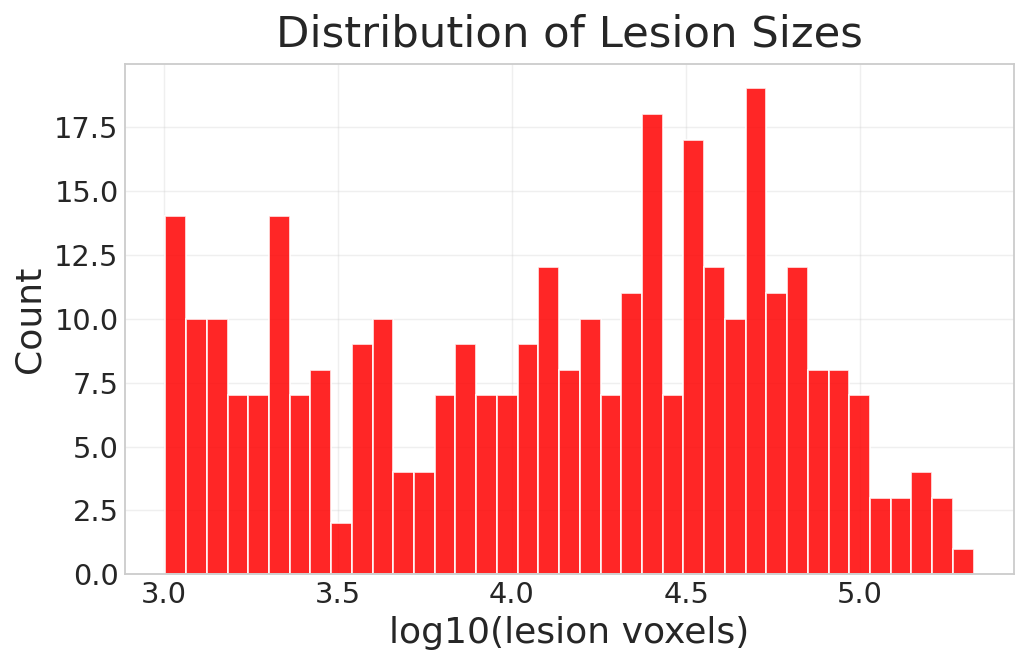

Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval_combined/figs/hist_lesion_logvox.png


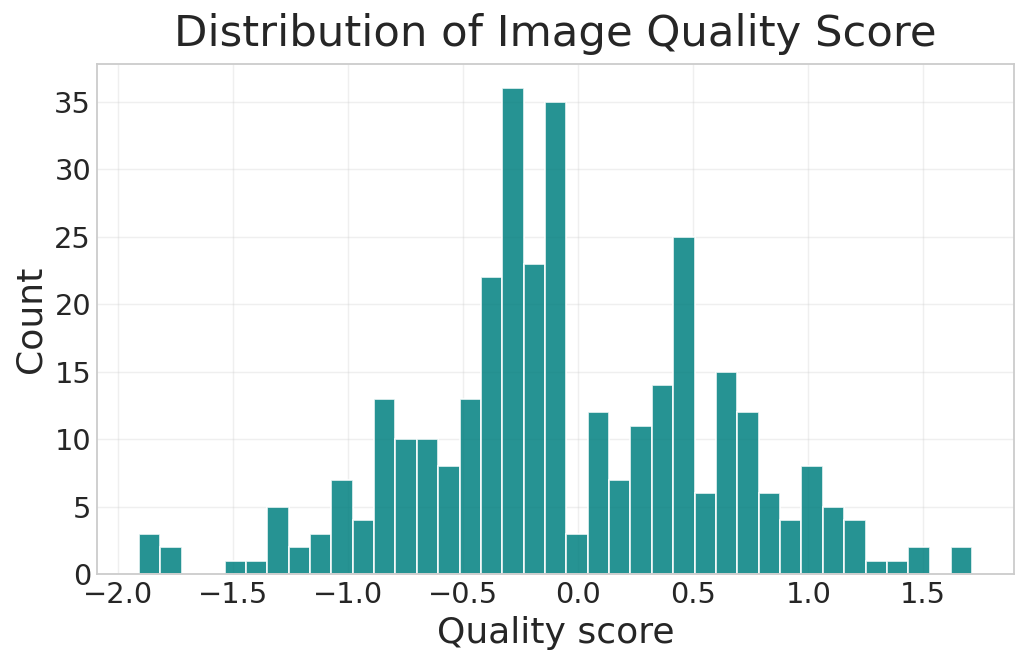

Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval_combined/figs/hist_quality_score.png


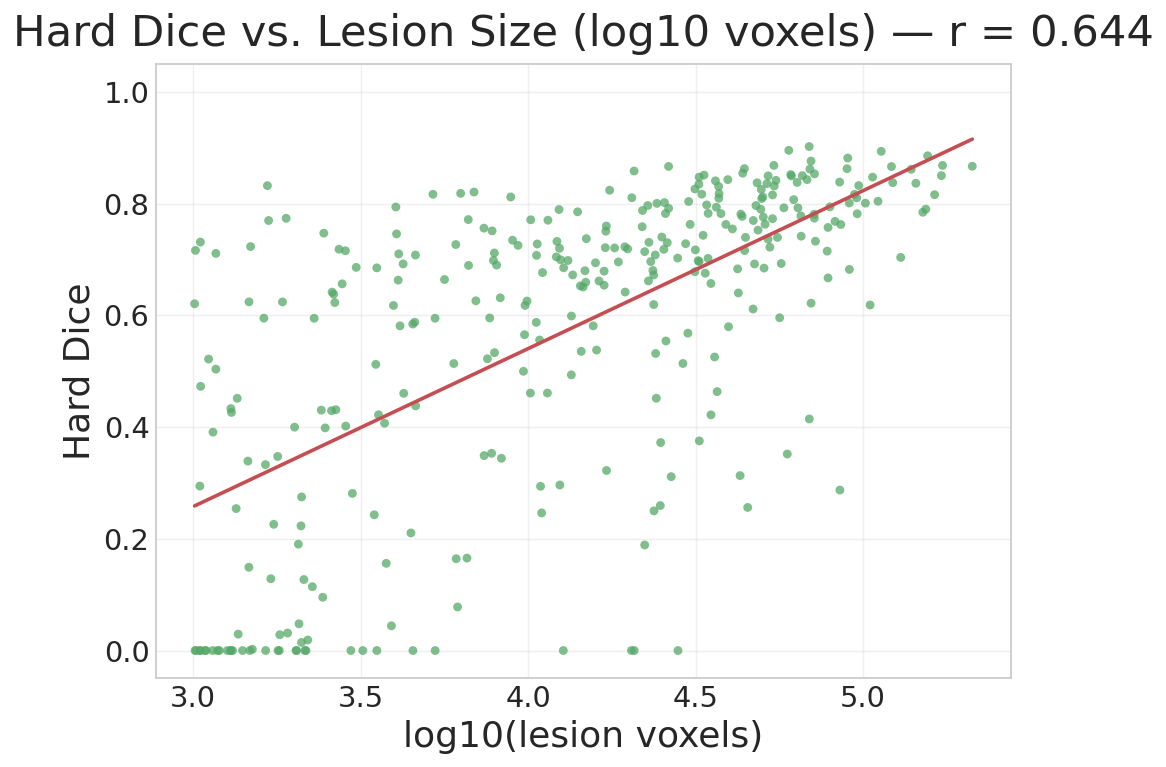

Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval_combined/figs/corr_hard_vs_logvox.png


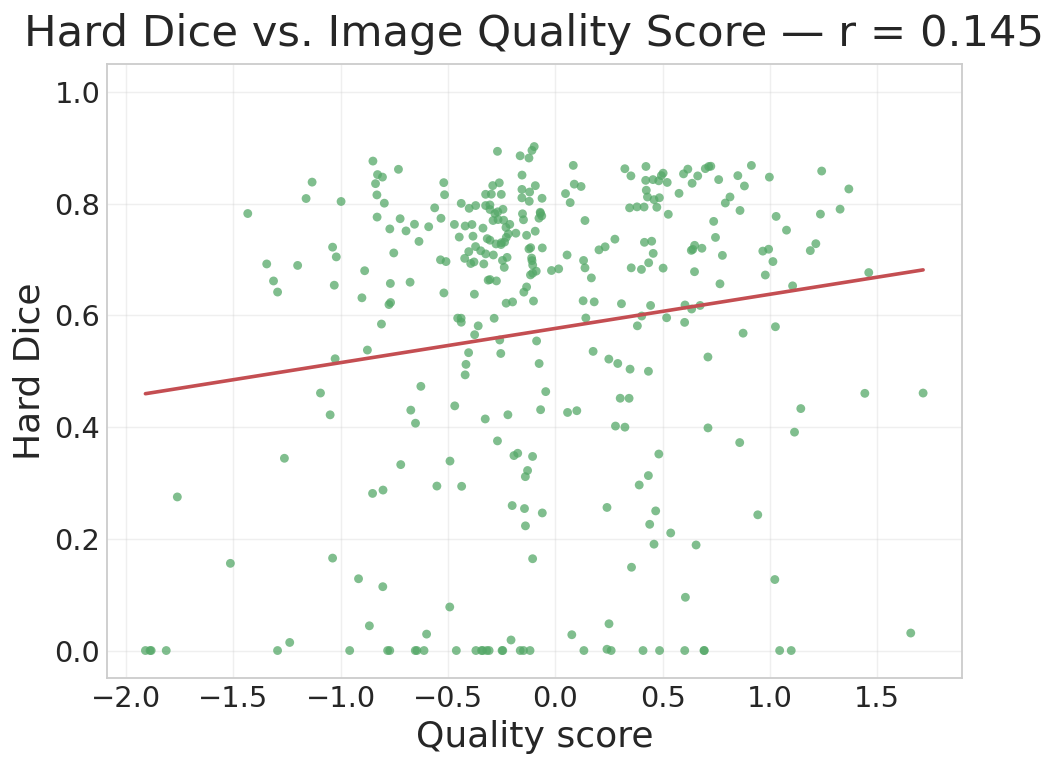

Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval_combined/figs/corr_hard_vs_quality.png

Summary:
  N cases (valid hard & size): 336
  Pearson r (Hard vs log10 size): 0.644
  Pearson r (Hard vs quality score): 0.145


In [8]:
# === Pretty distributions + correlations (COMBINED set) ===
from pathlib import Path
import csv, math
import numpy as np
import matplotlib.pyplot as plt

# ---- locate newest combined CSV ----
RUN_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813")
cand = list((RUN_DIR/"test_eval_combined").glob("test_metrics_with_manifest_COMBINED_*.csv"))
if not cand:
    raise FileNotFoundError("No combined CSV found in test_eval_combined/.")
CSV_PATH = max(cand, key=lambda p: p.stat().st_mtime)
OUT_DIR = RUN_DIR/"test_eval_combined"/"figs"; OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Using CSV:", CSV_PATH)

# ---- load rows ----
rows = []
with open(CSV_PATH, newline="") as f:
    rows = list(csv.DictReader(f))
if not rows:
    raise RuntimeError(f"No rows in {CSV_PATH}")

def col(name, cast=float):
    out = []
    for r in rows:
        try:
            v = r.get(name, "")
            out.append(cast(v))
        except Exception:
            out.append(float("nan"))
    return np.array(out, dtype=float)

# Core columns
hard   = col("hard_dice")
soft   = col("soft_dice")
vox    = col("voxels_clean", int).astype(float)
score  = col("score")
logvox = np.log10(np.where(vox>0, vox, np.nan))

# --- small helpers ---
def nan_pearson(x, y):
    m = (~np.isnan(x)) & (~np.isnan(y))
    if m.sum() < 3: return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

def fit_line(x, y):
    m = (~np.isnan(x)) & (~np.isnan(y))
    xs, ys = x[m], y[m]
    if xs.size < 2:
        return None, None
    A = np.vstack([xs, np.ones_like(xs)]).T
    b, a = np.linalg.lstsq(A, ys, rcond=None)[0]  # y = a + b*x
    return a, b

plt.style.use("seaborn-v0_8-whitegrid")
palette = {
    "size_hist": "#4C72B0",
    "score_hist": "#DD8452",
    "scatter": "#55A868",
    "line": "#C44E52",
}

# =============================
# 1) Distribution: Lesion size
# =============================
fig = plt.figure(figsize=(8,5.2), dpi=130)
ax = fig.add_subplot(111)
valid = ~np.isnan(logvox)
bins = np.linspace(np.nanmin(logvox[valid]), np.nanmax(logvox[valid]), 40)
ax.hist(logvox[valid], bins=bins, color="red", edgecolor="white", alpha=0.85)
ax.set_title("Distribution of Lesion Sizes", fontsize=24, pad=10)
ax.set_xlabel("log10(lesion voxels)", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
p = OUT_DIR/"hist_lesion_logvox.png"; plt.savefig(p, dpi=180); plt.show()
print("Saved", p)

# ==================================
# 2) Distribution: Image quality score
# ==================================
fig = plt.figure(figsize=(8,5.2), dpi=130)
ax = fig.add_subplot(111)
valid = ~np.isnan(score)
bins = np.linspace(np.nanmin(score[valid]), np.nanmax(score[valid]), 40)
ax.hist(score[valid], bins=bins, color="teal", edgecolor="white", alpha=0.85)
ax.set_title("Distribution of Image Quality Score", fontsize=24, pad=10)
ax.set_xlabel("Quality score", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
p = OUT_DIR/"hist_quality_score.png"; plt.savefig(p, dpi=180); plt.show()
print("Saved", p)

# =========================================
# 3) Correlation: Hard Dice vs lesion size
# =========================================
fig = plt.figure(figsize=(7.6,6.0), dpi=130)
ax = fig.add_subplot(111)
m = (~np.isnan(hard)) & (~np.isnan(logvox))
xs, ys = logvox[m], hard[m]
ax.scatter(xs, ys, s=24, color=palette["scatter"], alpha=0.75, edgecolor="none")
a, b = fit_line(xs, ys)
if a is not None:
    xx = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(xx, a + b*xx, linewidth=2.0, color=palette["line"])
r = nan_pearson(hard, logvox)
ax.set_title(f"Hard Dice vs. Lesion Size (log10 voxels) — r = {r:.3f}", fontsize=24, pad=10)
ax.set_xlabel("log10(lesion voxels)", fontsize=20)
ax.set_ylabel("Hard Dice", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
p = OUT_DIR/"corr_hard_vs_logvox.png"; plt.savefig(p, dpi=180); plt.show()
print("Saved", p)

# =========================================
# 4) Correlation: Hard Dice vs quality score
# =========================================
fig = plt.figure(figsize=(7.6,6.0), dpi=130)
ax = fig.add_subplot(111)
m = (~np.isnan(hard)) & (~np.isnan(score))
xs, ys = score[m], hard[m]
ax.scatter(xs, ys, s=24, color=palette["scatter"], alpha=0.75, edgecolor="none")
a, b = fit_line(xs, ys)
if a is not None:
    xx = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(xx, a + b*xx, linewidth=2.0, color=palette["line"])
r = nan_pearson(hard, score)
ax.set_title(f"Hard Dice vs. Image Quality Score — r = {r:.3f}", fontsize=24, pad=10)
ax.set_xlabel("Quality score", fontsize=20)
ax.set_ylabel("Hard Dice", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
p = OUT_DIR/"corr_hard_vs_quality.png"; plt.savefig(p, dpi=180); plt.show()
print("Saved", p)

# Quick text summary
print("\nSummary:")
print(f"  N cases (valid hard & size): {(~np.isnan(hard) & ~np.isnan(logvox)).sum()}")
print(f"  Pearson r (Hard vs log10 size): {nan_pearson(hard, logvox):.3f}")
print(f"  Pearson r (Hard vs quality score): {nan_pearson(hard, score):.3f}")